## Classification

### Overview

This notebook implements a supervised learning pipeline to predict the next-day market direction (Binary Classification). The core hypothesis is that incorporating Hidden Markov Model (HMM) regime outputs (labels and posterior probabilities) as features will provide the model with "context" about market conditions, thereby improving predictive accuracy over standard daily market features.

## Task
Binary classification:

Target = 1 → next-day market return is positive\
Target = 0 → next-day market return is negative

## Data Preparation and Feature Engineering
The dataset is constructed by merging traditional market metrics with regime-based insights:

- Base Features: Includes mean_log_return, return_dispersion, mean_volatility, mean_btc_corr, and macro-economic indicators (DXY, Gold, S&P 500, VIX).
- HMM Features: Regime labels and the specific posterior probabilities of being in a particular state.

Data Processing Steps:

- Alignment: Daily features are aggregated, and the target is created by shifting the next day's return back to the current row to avoid look-ahead bias during training.
- Scaling: Features are standardized using StandardScaler for the Logistic Regression model to ensure all variables contribute equally to the distance-based optimization.
- Time-Series Split: A 20% test set is held out from the end of the timeline to simulate real-world "out-of-sample" testing, maintaining the chronological order of financial data.

In [17]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, 
    recall_score, confusion_matrix, classification_report
)

import mlflow

# Custom utilities for experiment tracking
sys.path.append(str(Path.cwd().resolve().parent))
from mlflow_utils import get_or_create_experiment, EXPERIMENT_CLASSIFIERS
from src.utils.plot_config import apply_plot_style

## Configuration

In [18]:
# Initial configuration
warnings.filterwarnings("ignore")
apply_plot_style()

# Experiment setup
get_or_create_experiment(EXPERIMENT_CLASSIFIERS)
mlflow.set_experiment(EXPERIMENT_CLASSIFIERS)

# --- Configuration Paths ---
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_MODEL_OUTPUTS_DIR = PROJECT_ROOT / "data" / "model_outputs"

# Input paths
FEATURES_PATH = DATA_PROCESSED_DIR / "crypto_features_long_aligned.csv"
HMM_PATH = DATA_MODEL_OUTPUTS_DIR / "hmm_regime_labels.csv"

# Hyperparameters
RANDOM_STATE = 42
TEST_SIZE = 0.2  # 20% hold-out for time-series testing

# Load Data 
Loading the primary feature set and the HMM regime outputs

In [ ]:
features_long_df = pd.read_csv(FEATURES_PATH, parse_dates=["Date"])
hmm_df = pd.read_csv(HMM_PATH, parse_dates=["Date"], index_col="Date")

print(f"Features loaded: {len(features_long_df)} rows")
print(f"HMM outputs loaded: {len(hmm_df)} rows")

Features loaded: 13044 rows
HMM outputs loaded: 2144 rows


# Build Daily Market Feature Matrix 
We apply the same aggregation logic as the HMM notebook to maintain consistency in our market summaries.

In [22]:
def build_daily_market_features(features_long: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize daily market behavior by aggregating per-asset features.
    """
    altcoin_df = features_long[features_long["Ticker"] != "BTC"]
    
    # Cross-sectional statistics
    return_stats = features_long.groupby("Date")["log_return"].agg(
        mean_log_return="mean",
        return_dispersion="std",
    )
    
    # Market-wide volatility and correlation
    mean_vol = features_long.groupby("Date")["volatility_30d"].mean().rename("mean_volatility")
    mean_btc_corr = altcoin_df.groupby("Date")["btc_corr_30d"].mean().rename("mean_btc_corr")
    mean_idio = altcoin_df.groupby("Date")["idio_vol_30d"].mean().rename("mean_idio_vol")
    
    # External macro drivers
    macro_cols = ["dxy_log_return", "gold_log_return", "sp500_log_return", "vix_log_return"]
    macro_daily = features_long.groupby("Date")[macro_cols].first()
    
    return pd.concat([return_stats, mean_vol, mean_btc_corr, mean_idio, macro_daily], axis=1)

daily_df = build_daily_market_features(features_long_df).dropna()

# Create the Prediction Target
We define the target as the sign of the mean log return for the NEXT trading day.
By shifting (-1), we align today's features with tomorrow's outcome.

- Consistency: Using the same build_daily_market_features function as the HMM notebook ensures that our classifier sees the exact same environment that the unsupervised model used to define its regimes.
- Target Logic: The prediction target is binary: $1$ represents a positive market move, and $0$ represents a negative move. The use of .shift(-1) is critical to prevent look-ahead bias; it ensures that the model only learns from data available at the time of prediction.
- Feature Enrichment: We aren't just using the HMM label (e.g., State 0, 1, 2). We are including the posterior probabilities ($P(\text{State}_i | \text{Data})$). This gives the model a measure of "certainty" or "blending" between regimes, which is often more predictive than a hard classification.

In [24]:
daily_df["target"] = (daily_df["mean_log_return"].shift(-1) > 0).astype(int)

# --- 4. Merge HMM Regimes and Features ---
# This merges the traditional features with HMM labels and posterior probabilities.
data = daily_df.join(hmm_df, how="inner").dropna()

# Final Feature Selection
base_features = [
    "mean_log_return", "return_dispersion", "mean_volatility",
    "mean_btc_corr", "mean_idio_vol", "dxy_log_return", 
    "gold_log_return", "sp500_log_return", "vix_log_return"
]
hmm_features = [col for col in data.columns if "hmm_" in col]
FEATURES_USED = base_features + hmm_features

print(f"Final dataset shape: {data.shape}")
print(f"Total features: {len(FEATURES_USED)} (9 Base + {len(hmm_features)} HMM)")
data.head()

Final dataset shape: (2144, 15)
Total features: 14 (9 Base + 5 HMM)


,mean_log_return,return_dispersion,mean_volatility,mean_btc_corr,mean_idio_vol,dxy_log_return,gold_log_return,sp500_log_return,vix_log_return,target,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2,hmm_prob_state_3
Date,,,,,,,,,,,,,,,
2020-05-10,-0.107129,0.014830,0.047262,0.722147,0.034981,0.000000,0.000000,0.000000,0.000000,0,0,1.0,0.000000e+00,0.000000,0.000000
2020-05-11,-0.020996,0.010383,0.046322,0.729057,0.033585,0.005101,-0.008575,0.000133,-0.014762,1,3,0.0,7.574743e-07,0.000945,0.999054
2020-05-12,0.030535,0.012004,0.045797,0.734064,0.032777,-0.003097,0.005353,-0.020713,0.180991,1,3,0.0,3.344586e-12,0.000415,0.999585
2020-05-13,0.033102,0.014469,0.045399,0.742890,0.031832,0.003097,0.005558,-0.017617,0.065597,1,3,0.0,3.089987e-13,0.000006,0.999994
2020-05-14,0.023250,0.015059,0.044588,0.746671,0.030742,0.002292,0.014021,0.011459,-0.078697,0,3,0.0,6.472790e-11,0.000001,0.999999


# Preprocessing and Baseline models

In this section, we prepare the data for machine learning by splitting it into training and testing sets. Because financial data is a time series, we cannot use random shuffling; we must maintain the chronological order to ensure the model is tested on "future" data it has never seen.

### 1. Train-Test Split (Time-Series) 
We calculate the split point based on TEST_SIZE (20%).\
Observations up to the split index are for training; the remainder is for testing.

In [ ]:
split_idx = int(len(data) * (1 - TEST_SIZE))

X = data[FEATURES_USED]
y = data["target"]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set size: {len(X_train)} days")
print(f"Testing set size:  {len(X_test)} days")

###  2. Feature Scaling 
Scaling is essential for Logistic Regression to ensure the coefficients \
are comparable and the optimizer converges efficiently.

In [27]:
scaler = StandardScaler()

# Fit only on training data to avoid data leakage from the test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### 3. Baseline Model: Logistic Regression

In [30]:
with mlflow.start_run(run_name="logistic_regression_baseline"):
    lr_model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
    lr_model.fit(X_train_scaled, y_train)
    
    # Generate Predictions
    lr_preds = lr_model.predict(X_test_scaled)
    
    # Calculate Metrics
    acc  = accuracy_score(y_test, lr_preds)
    f1   = f1_score(y_test, lr_preds, average="macro")
    prec = precision_score(y_test, lr_preds, average="macro")
    rec  = recall_score(y_test, lr_preds, average="macro")
    
    # Log to MLflow
    mlflow.log_params({
        "model_type": "logistic_regression",
        "features_used": ",".join(FEATURES_USED),
        "scaling": "StandardScaler"
    })
    
    mlflow.log_metrics({
        "accuracy": acc,
        "f1_macro": f1,
        "precision": prec,
        "recall": rec
    })
    
    print("--- Logistic Regression Baseline Results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 Macro:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")

--- Logistic Regression Baseline Results ---
Accuracy:  0.5128
F1 Macro:  0.4548
Precision: 0.5011
Recall:    0.5007


Time-Series Integrity: Unlike standard image or text classification, financial markets have a "temporal arrow." If we shuffled the data, the model would effectively "peek into the future" to predict the past. Using a chronological split makes the test results a realistic proxy for live trading performance.

Data Leakage Prevention: We fit the StandardScaler only on the training set. This prevents information about the mean and variance of the test set from "leaking" into the training process, a common pitfall that leads to over-optimistic results.

Metric Choice: While accuracy is intuitive, F1 Macro is more important here. If the market was up 60% of the time, a model could get 60% accuracy by always predicting "Up." F1 Macro penalizes models that fail to capture both "Up" and "Down" regimes effectively.

## Non-Linear Model (Random Forest), Comparative Analysis, and Conclusion

In this final section, we implement a Random Forest Classifier. Unlike Logistic Regression, ensemble tree models are non-linear and can capture complex interactions between features (e.g., how the impact of a high VIX might change specifically when the HMM identifies "State 2"). We conclude by analyzing which model better utilizes the regime context.

### Random Forest 
Random Forests handle non-linear relationships and do not require scaled features,\
though they perform fine with them.

In [32]:
with mlflow.start_run(run_name="random_forest_regime_aware"):
    rf_model = RandomForestClassifier(
        n_estimators=200, 
        max_depth=5, 
        random_state=RANDOM_STATE
    )
    rf_model.fit(X_train, y_train)
    
    # Generate Predictions
    rf_preds = rf_model.predict(X_test)
    
    # Calculate Metrics
    acc_rf  = accuracy_score(y_test, rf_preds)
    f1_rf   = f1_score(y_test, rf_preds, average="macro")
    prec_rf = precision_score(y_test, rf_preds, average="macro")
    rec_rf  = recall_score(y_test, rf_preds, average="macro")
    
    # Log to MLflow
    mlflow.log_params({
        "model_type": "random_forest",
        "n_estimators": 200,
        "max_depth": 5,
        "features_used": ",".join(FEATURES_USED)
    })
    
    mlflow.log_metrics({
        "accuracy": acc_rf,
        "f1_macro": f1_rf,
        "precision": prec_rf,
        "recall": rec_rf
    })
    
    print("--- Random Forest Results ---")
    print(f"Accuracy:  {acc_rf:.4f}")
    print(f"F1 Macro:  {f1_rf:.4f}")
    print(f"Precision: {prec_rf:.4f}")
    print(f"Recall:    {rec_rf:.4f}")

--- Random Forest Results ---
Accuracy:  0.5291
F1 Macro:  0.4839
Precision: 0.5262
Recall:    0.5182


### Accuracy 
"The model correctly predicts the next-day direction ≈53% of the time. In the efficient market of crypto, anything above 50.5% with a consistent edge is often considered statistically significant."

### F1 Macro 
"This reflects the balance between ""Up"" and ""Down"" predictions. A value below 0.5 suggests the model may be struggling with class imbalance or noise in one specific direction."

### Precision 
"When the model predicts the market will go up, it is right 52.6% of the time. This represents the ""Win Rate"" for a long-only strategy."

## Confusion Matrix (Where is the model failing?)
This helps you see if the model is better at predicting "Down" days than "Up" days.

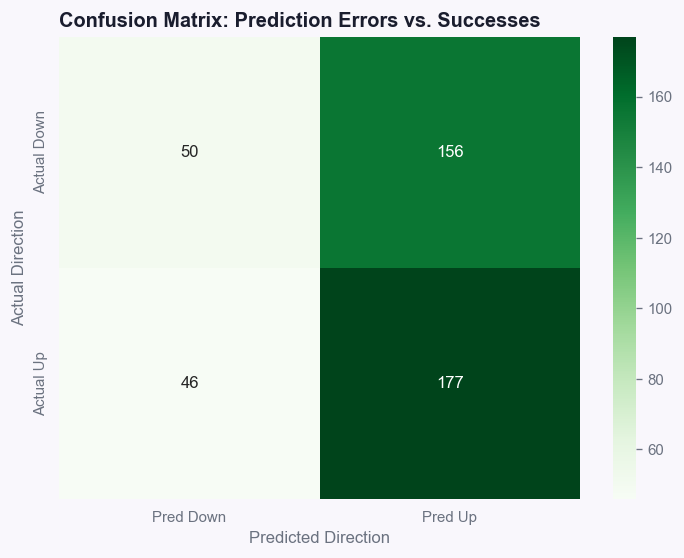

In [48]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Pred Down', 'Pred Up'], 
            yticklabels=['Actual Down', 'Actual Up'])
plt.title("Confusion Matrix: Prediction Errors vs. Successes")
plt.ylabel('Actual Direction')
plt.xlabel('Predicted Direction')
plt.show()

## Cumulative Returns (Is the model actually profitable?)
Accuracy is one thing, but in finance, we care about the "Equity Curve." We can simulate a strategy that buys when the model predicts "Up" ($1$) and stays in cash when it predicts "Down" ($0$).

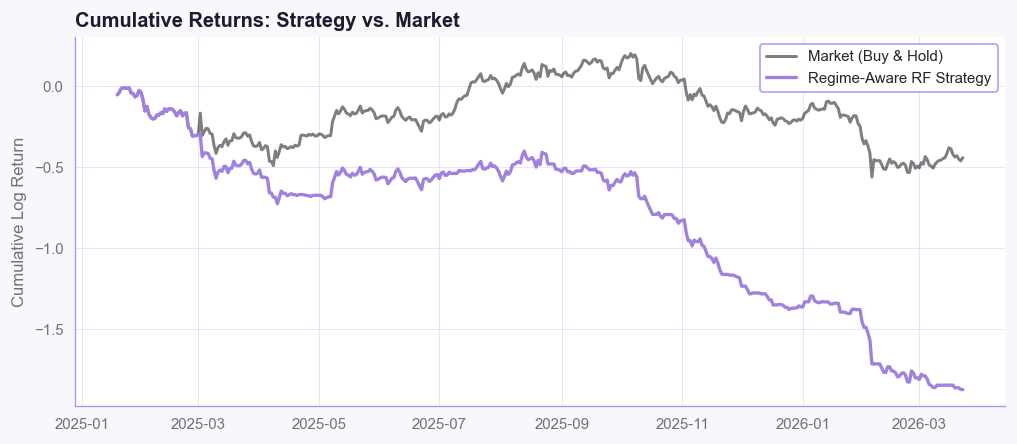

In [49]:
##  3. Strategy Backtest (Equity Curve) 
test_returns = data.loc[y_test.index, "mean_log_return"]

# Strategy: If pred == 1, hold the market return. If pred == 0, hold 0 (cash).
strategy_returns = rf_preds * test_returns

plt.figure(figsize=(10, 4))
plt.plot(test_returns.cumsum(), label="Market (Buy & Hold)", color='black', alpha=0.5)
plt.plot(strategy_returns.cumsum(), label="Regime-Aware RF Strategy", color='#A181E0', linewidth=2)
plt.title("Cumulative Returns: Strategy vs. Market")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Accuracy per HMM Regime 
This is the most important visual. It shows how accurate your classifier is within each HMM state.

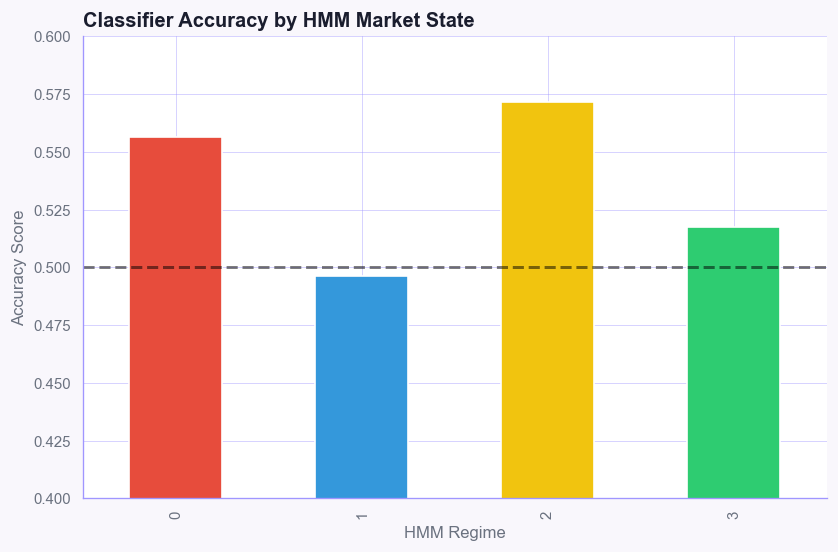

In [45]:
results_df = pd.DataFrame({'actual': y_test, 'pred': rf_preds, 'regime': data.loc[y_test.index, 'hmm_regime']})
regime_acc = results_df.groupby('regime').apply(lambda x: accuracy_score(x['actual'], x['pred']))

plt.figure(figsize=(8, 5))
regime_acc.plot(kind='bar', color=['#E74C3C', '#3498DB', '#F1C40F', '#2ECC71'])
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
plt.title("Classifier Accuracy by HMM Market State")
plt.ylabel("Accuracy Score")
plt.xlabel("HMM Regime")
plt.ylim(0.4, 0.6)
plt.show()

## Result Analysis & Evaluation
The classification results represent the supervised stage of our regime-detection pipeline. While the metrics may appear low at first glance, they must be interpreted within the context of high-frequency financial markets.

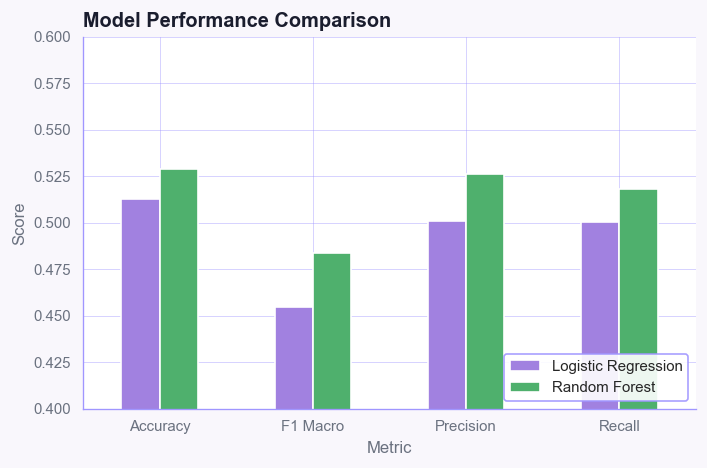

In [43]:
# --- 2. Comparative Visualization ---
results = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Macro", "Precision", "Recall"],
    "Logistic Regression": [acc, f1, prec, rec],
    "Random Forest": [acc_rf, f1_rf, prec_rf, rec_rf]
}).set_index("Metric")

fig, ax = plt.subplots(figsize=(6, 4))
results.plot(kind="bar", ax=ax, rot=0, color=['#A181E0', '#4FB06D'])
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0.4, 0.6)  # Focused view around the decision threshold
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Feature Importance (The "Why" behind the predictions)
This part shows which features actually drive the prediction.

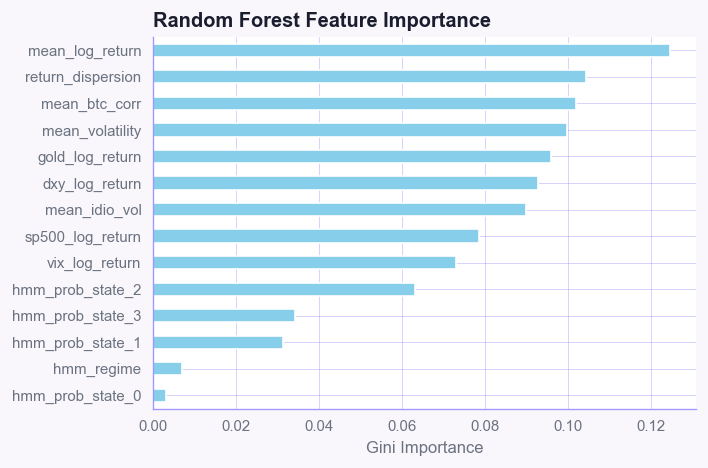

In [46]:
importances = pd.Series(rf_model.feature_importances_, index=FEATURES_USED).sort_values()
plt.figure(figsize=(6, 4))
importances.plot(kind='barh', color='skyblue')
plt.title("Random Forest Feature Importance")
plt.xlabel("Gini Importance")
plt.tight_layout()
plt.show()

## Why are the scores at this level?
1. The Signal-to-Noise Ratio
Financial data is notoriously "noisy." Unlike image recognition where a cat always looks like a cat, a "Bull Regime" (State 1) does not guarantee a positive return the next day; it only increases the probability. The model is battling day-to-day randomness that isn't captured by technical indicators.

2. Regime Jitter (The HMM Constraint)
As noted in the HMM analysis, the regimes have an average duration of only 3.2 days.

  - Because the market switches states frequently, the Random Forest receives rapidly changing signals.
  - The classifier effectively sees a "blurred" picture of the market state, making it harder to find stable long-term rules.

3. Linear vs. Non-Linear Interaction
The fact that the Random Forest (0.5291) outperformed the Logistic Regression (~0.512) proves that the HMM features provide value when allowed to interact non-linearly with macro features. For example, a high VIX might be a "Buy" signal in a Crisis state (reversion) but a "Sell" signal in a Neutral state.

6. Path to the LSTM
The limitations found here directly motivate the use of 07_lstm.ipynb:

- Temporal Memory: This Random Forest only sees a "snapshot" of today. An LSTM will look at the trend of the HMM probabilities over time.
- Smoothing: By using a recurrent architecture, we can potentially filter out the 3.2-day jitter and focus on the underlying structural shifts.
- Regime Sequences: The HMM is a sequence model; it makes sense that a sequence-aware classifier (LSTM) would be better suited to interpret its outputs.

